In [38]:
import pandas as pd
import numpy as np
import rapidfuzz
import matplotlib.pyplot as plt
import json

from src.name_cleanup import value_to_cleaned_str
from src.levenshtein_c.levenshtein_cython import lde_similarity
from src.set_costs import (
    set_cost,
    set_cost_two_way,
    set_cost_from_codes,
    set_cost_two_way_from_codes,
)

## Preparations

### Data

In [2]:
connected_migrations = pd.read_csv("outputs/csv/connected_migrations_from_database.csv")
connected_migrations = connected_migrations.map(value_to_cleaned_str)

### Weighted Levenshtein weights

In [3]:
size = 256
consonants = "bcdfghjklmnpqrstvwxz"
consonants_upper = consonants.upper()
consonants_both_cases = consonants + consonants_upper
vowels = "aeiouyäöå"
vowels_upper = vowels.upper()
vowels_both_cases = vowels + vowels_upper
all = consonants_both_cases + vowels_both_cases

In [4]:
vowel_codes = [ord(c) for c in vowels]
vowel_upper_codes = [ord(c) for c in vowels_upper]
consonant_codes = [ord(c) for c in consonants]
consonant_upper_codes = [ord(c) for c in consonants_upper]
all_codes = (
    vowel_codes + vowel_upper_codes + consonant_codes + consonant_upper_codes
)

punctuation_codes = (ord("."), ord("?"))
colon_code = (ord(":"),)

In [5]:
insert_costs = np.full(size, fill_value=2.0, dtype=np.float64)

delete_costs = np.ones(size, dtype=np.float64)
set_cost(delete_costs, 4.0, ".")
set_cost(delete_costs, 0.0, "?")
set_cost(delete_costs, 4.0, ":")

In [6]:
substitute_costs = np.ones((size, size), dtype=np.float64)

set_cost_two_way_from_codes(substitute_costs, 4.0, all_codes, colon_code)
set_cost_two_way_from_codes(substitute_costs, 4.0, all_codes, punctuation_codes)

# vowel-vowel substitute costs
set_cost_from_codes(substitute_costs, 1.0, vowel_codes, vowel_codes)
set_cost_from_codes(substitute_costs, 2.0, vowel_upper_codes, vowel_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, vowel_upper_codes)

# consonant-consonant substitute costs
set_cost_from_codes(substitute_costs, 2.0, consonant_codes, consonant_codes)
set_cost_from_codes(substitute_costs, 4.0, consonant_upper_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 6.0, consonant_codes, consonant_upper_codes)

# vowel-consonant substitute costs
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, consonant_codes)
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 6.0, vowel_upper_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 9.0, vowel_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 9.0, vowel_upper_codes, consonant_codes)

# remove possible substitute cost for self
substitute_costs[np.diag_indices(256)] = len(substitute_costs.diagonal()) * [0]

In [7]:
pair_specific_sub_costs = (
    (0.65, "o", "a"),
    (0.0 , "k", "c"),
    (0.6, "i", "e"),
    (0.7, "e", "i"),
    (0.25, "d", "j"),
    (0.75, "i", "j"),
    (0.15, "g", "k"),
    (0.15, "å", "o"),
    (0.15, "b", "p"),
    (0.15, "d", "t"),
    (0.35, "o", "u"),
    (0.3, "w", "v"),
    (0.0 , "k", "x"),
    (0.25, "e", "ä"),
    (0.05, "o", "å")
)

for p in pair_specific_sub_costs:
    set_cost(substitute_costs, p[0], p[1], p[2])

In [8]:
deabbreviate_costs = {}

deabbreviate_costs[":"] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs[":"], 0.25, vowel_codes + consonant_codes)

deabbreviate_costs["."] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs["."], 2.0, vowel_codes + consonant_codes)

deabbreviate_costs["?"] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs["?"], 2.0, vowel_codes + consonant_codes)

## Normalizing

In [9]:
probably_connected = connected_migrations[
    connected_migrations.apply(
    lambda x: lde_similarity(
            x["source"], x["emigrated_parish"],
            substitute_costs, insert_costs, delete_costs,
            deabbreviate_costs
        ) >= 0.6,
        axis=1
    )
]

In [10]:
probably_connected_sources = probably_connected[["emigrated_parish", "source"]]
probably_connected_destinations = probably_connected[["immigrated_parish", "destination"]]

In [11]:
probably_connected_sources = probably_connected_sources.rename({"emigrated_parish": "actual", "source": "written"}, axis="columns")
probably_connected_destinations = probably_connected_sources.rename({"immigrated_parish": "actual", "destination": "written"}, axis="columns")

In [12]:
spellings = pd.concat(
    [
        probably_connected_sources,
        probably_connected_destinations
    ]
)

In [13]:
differing_spellings = spellings[spellings["actual"] != spellings["written"]]

<Axes: ylabel='actual,written'>

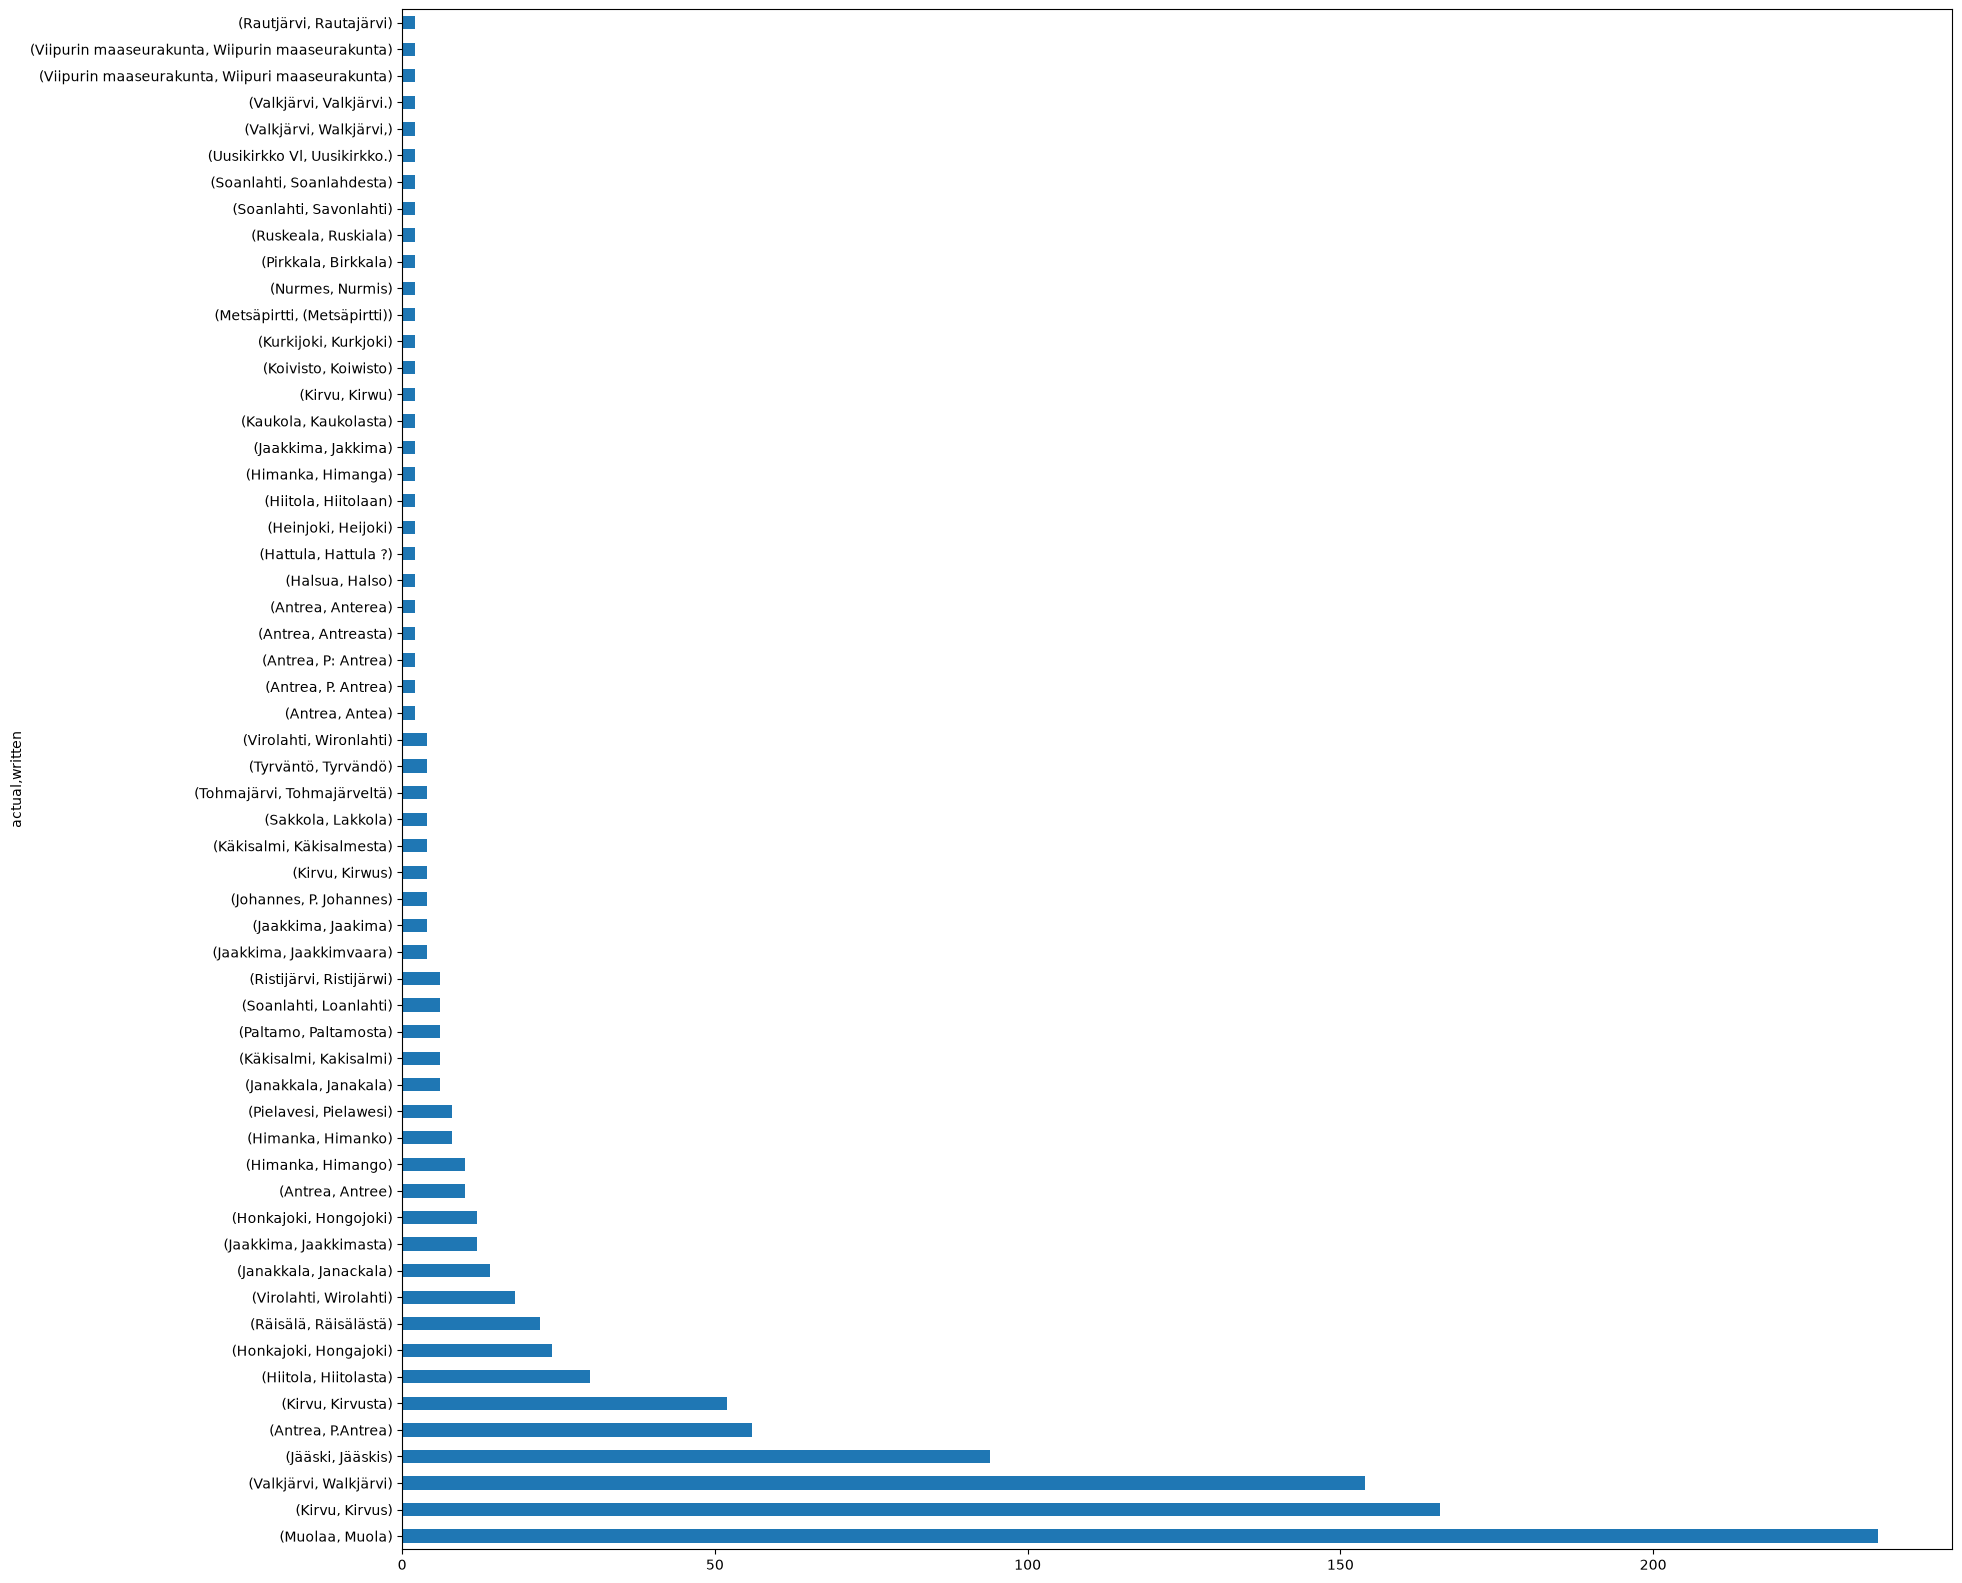

In [14]:
fig, axs = plt.subplots(figsize=(20, 20))
differing_spellings.value_counts().plot.barh(ax=axs)

In [ ]:
with open("outputs/json/spellings/db_normalizing.json", "w") as fp:
    json.dump(
        {x[0]: x[1] for x in differing_spellings[["written", "actual"]].to_numpy()},
        fp,
        ensure_ascii=False
    )

## People's names?

In [16]:
names = pd.concat(
    [
        connected_migrations["first_name"],
        connected_migrations["first_name.1"],
        connected_migrations["patronym"],
        connected_migrations["patronym.1"],
        connected_migrations["last_name"],
        connected_migrations["last_name.1"],
    ]
).to_list()
names_n = pd.concat(
    [
        connected_migrations["first_nameN"],
        connected_migrations["first_nameN.1"],
        connected_migrations["patronymN"],
        connected_migrations["patronymN.1"],
        connected_migrations["last_nameN"],
        connected_migrations["last_nameN.1"],
    ]
).to_list()

In [17]:
name_norm_df = pd.DataFrame({"name": names, "name_n": names_n}).drop_duplicates()

In [18]:
pd.DataFrame(name_norm_df).to_csv(
    "outputs/csv/person_name_normalization.csv",
    index=False
)